# 03 — Logistic Regression Baseline Model

### Project: Online Retail Engagement Risk Prediction
### Notebook: 03_modeling_logistic_regression.ipynb

**Goals:**
- Train an interpretable logistic regression baseline for 30-day churn prediction
- Evaluate model performance using threshold-independent metrics (ROC-AUC, PR-AUC)
- Analyze coefficients and diagnose multicollinearity
- Conduct lift and decile analysis to quantify business value

**Inputs:**
- `data/processed/modeling_dataset.parquet` — full labeled modeling dataset from notebook 02

**Outputs:**
- `data/processed/lr_test_predictions.parquet` — test set predictions for threshold tuning in notebook 04

**Steps:**
- Load modeling dataset and define features and target
- Time-based train/test split (last 20% of snapshots as test)
- Re-evaluate baseline heuristics on test set
- Train logistic regression pipeline with StandardScaler and balanced class weights
- Evaluate model — ROC-AUC, PR-AUC, confusion matrix
- Coefficient analysis
- Multicollinearity diagnostics — correlation matrix and VIF
- Lift and decile analysis
- Persist test set predictions to parquet

In [15]:
# ─────────────────────────────────────────────────────────────
# Imports
# ─────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

In [16]:
# ─────────────────────────────────────────────────────────────
# Load Modeling Dataset
# ─────────────────────────────────────────────────────────────

DATA_PATH = Path("../data/processed/modeling_dataset.parquet")
model_df  = pd.read_parquet(DATA_PATH)

model_df["snapshot_date"] = pd.to_datetime(model_df["snapshot_date"])

print("Shape:", model_df.shape)
print("Churn rate:", model_df["label"].mean().round(4))
print("Date range:", model_df["snapshot_date"].min().date(),
      "→", model_df["snapshot_date"].max().date())

Shape: (120261, 17)
Churn rate: 0.7098
Date range: 2009-12-07 → 2010-11-08


In [17]:
# ─────────────────────────────────────────────────────────────
# Define Features and Target
# ─────────────────────────────────────────────────────────────

feature_cols = [
    "recency_days",
    "orders_7d",  "revenue_7d",  "items_7d",
    "orders_30d", "revenue_30d", "items_30d",
    "orders_90d", "revenue_90d", "items_90d",
    "lifetime_orders", "lifetime_revenue",
    "cancel_count", "cancellation_rate",
]

X = model_df[feature_cols].copy()
y = model_df["label"].astype(int).copy()

print("Feature matrix shape:", X.shape)
print("Churn rate (y.mean):", y.mean().round(4))

Feature matrix shape: (120261, 14)
Churn rate (y.mean): 0.7098


## Time-Based Train/Test Split

Standard random splitting is not appropriate for time-series data — it would
allow future snapshots to leak into the training set, inflating performance
estimates that would collapse in deployment.

Instead we split on snapshot date: the first 80% of snapshot dates form the
training set and the final 20% form the test set. This mirrors real deployment
conditions — the model is always trained on the past and evaluated on the future.

In [18]:
# ─────────────────────────────────────────────────────────────
# Time-Based Train/Test Split
# Train: first 80% of snapshots
# Test:  final 20% of snapshots
# ─────────────────────────────────────────────────────────────

snapshots_sorted = sorted(model_df["snapshot_date"].unique())
cut              = int(len(snapshots_sorted) * 0.8)

train_snaps = set(snapshots_sorted[:cut])
test_snaps  = set(snapshots_sorted[cut:])

train_idx = model_df["snapshot_date"].isin(train_snaps)
test_idx  = model_df["snapshot_date"].isin(test_snaps)

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]

print(f"Train snapshots: {len(train_snaps)}  |  "
      f"Test snapshots: {len(test_snaps)}")
print(f"Train shape:     {X_train.shape}  |  "
      f"Test shape:  {X_test.shape}")
print(f"Train churn rate: {y_train.mean().round(4)}  |  "
      f"Test churn rate:  {y_test.mean().round(4)}")

Train snapshots: 38  |  Test snapshots: 10
Train shape:     (83709, 14)  |  Test shape:  (36552, 14)
Train churn rate: 0.7187  |  Test churn rate:  0.6894


In [19]:
# ─────────────────────────────────────────────────────────────
# Baseline Evaluation on Test Set
# Recency heuristic vs. all-churn classifier
# ─────────────────────────────────────────────────────────────

RECENCY_THRESHOLD = 30
recency_pred   = (X_test["recency_days"] > RECENCY_THRESHOLD).astype(int)
all_churn_pred = np.ones_like(y_test)

print("=" * 50)
print(f"{'Metric':<20} {'Recency':>10} {'All-Churn':>10}")
print("=" * 50)

metrics = [
    ("Accuracy",  accuracy_score,  {}),
    ("Precision", precision_score, {"zero_division": 0}),
    ("Recall",    recall_score,    {"zero_division": 0}),
]

for name, fn, kwargs in metrics:
    r = fn(y_test, recency_pred,   **kwargs)
    a = fn(y_test, all_churn_pred, **kwargs)
    print(f"{name:<20} {r:>10.4f} {a:>10.4f}")

print("=" * 50)

Metric                  Recency  All-Churn
Accuracy                 0.6341     0.6894
Precision                0.7416     0.6894
Recall                   0.7202     1.0000


## Baseline Results

The all-churn classifier achieves ~68.9% accuracy — equal to the base churn rate.
Any useful ML model must beat this on discrimination metrics, not just accuracy.

The recency heuristic underperforms the all-churn baseline at ~52% accuracy,
confirming the finding from notebook 02: recency alone is insufficient. A model
that incorporates frequency and monetary signals alongside recency is needed.

We now train a logistic regression pipeline with two key design decisions:
- **StandardScaler:** Normalizes features to zero mean and unit variance.
  Logistic regression uses gradient descent — features on vastly different
  scales cause uneven gradient steps and slow or unstable convergence.
- **class_weight="balanced":** Adjusts the loss function to upweight the
  minority class (non-churners). Without this, the model learns to predict
  the majority class (churn) by default due to the ~69% base rate.

In [20]:
# ─────────────────────────────────────────────────────────────
# Logistic Regression Pipeline
# StandardScaler + LogisticRegression with balanced class weights
# ─────────────────────────────────────────────────────────────

log_reg = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

log_reg.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [21]:
# ─────────────────────────────────────────────────────────────
# Model Evaluation — Default Threshold (0.5)
# ─────────────────────────────────────────────────────────────

proba_test = log_reg.predict_proba(X_test)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)

print("=" * 55)
print(" Logistic Regression — Default Threshold (0.5)")
print("=" * 55)
print(f"ROC-AUC:   {roc_auc_score(y_test, proba_test):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, proba_test):.4f}")
print(f"Precision: {precision_score(y_test, pred_test, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, pred_test):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, pred_test):.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, pred_test)}")
print(f"\nClassification Report:\n"
      f"{classification_report(y_test, pred_test, digits=3, zero_division=0)}")

 Logistic Regression — Default Threshold (0.5)
ROC-AUC:   0.6992
PR-AUC:    0.8116
Precision: 0.7873
Recall:    0.7504
Accuracy:  0.6882

Confusion Matrix:
[[ 6244  5109]
 [ 6289 18910]]

Classification Report:
              precision    recall  f1-score   support

           0      0.498     0.550     0.523     11353
           1      0.787     0.750     0.768     25199

    accuracy                          0.688     36552
   macro avg      0.643     0.650     0.646     36552
weighted avg      0.698     0.688     0.692     36552



## Model Evaluation

**ROC-AUC of 0.699 and PR-AUC of 0.812** — strong performance for a simple
logistic regression model with no hyperparameter tuning. Adding cancellation
features (`cancel_count`, `cancellation_rate`) produced negligible performance
change (+0.002 PR-AUC, flat ROC-AUC), consistent with the expectation that
logistic regression cannot exploit sparse, nonlinear dissatisfaction signals
effectively. The cancellation features are expected to contribute more
meaningfully in notebook 05 where XGBoost can capture interaction effects
between cancellation behavior and recency or order frequency.

### Why PR-AUC is the primary metric

With a ~69% base churn rate, ROC-AUC can be misleadingly optimistic — it
evaluates performance across both classes, including the majority non-churn
class where the model has an easy job. PR-AUC focuses exclusively on the
positive (churn) class, directly measuring the precision-recall tradeoff
that matters for re-engagement targeting. A PR-AUC of 0.812 means the model
maintains strong precision even as recall increases — indicating well-calibrated
churn probabilities across the full scoring range.

### Confusion matrix breakdown

At the default 0.5 threshold:
- **True Positives (18,910):** Churners correctly identified
- **False Negatives (6,289):** Churners missed — customers who left without
  being flagged
- **True Negatives (6,244):** Non-churners correctly cleared
- **False Positives (5,109):** Non-churners incorrectly flagged for outreach

The model catches ~75% of churners at ~79% precision — a reasonable starting
point that will be improved through threshold tuning in notebook 04.

### Note on the default 0.5 threshold

The 0.5 threshold is arbitrary and rarely optimal. With balanced class weights
shifting the model's probability outputs, the optimal threshold is likely
substantially below 0.5. Threshold tuning is addressed in notebook 04.

In [22]:
# ─────────────────────────────────────────────────────────────
# Coefficient Analysis
# Coefficients are on standardized features — magnitudes are
# directly comparable across features
# ─────────────────────────────────────────────────────────────

coef    = log_reg.named_steps["clf"].coef_[0]
coef_df = (
    pd.DataFrame({"feature": feature_cols, "coefficient": coef})
    .sort_values("coefficient", ascending=False)
    .reset_index(drop=True)
)

print("Logistic Regression Coefficients (standardized features):")
print(coef_df.to_string(index=False))

Logistic Regression Coefficients (standardized features):
          feature  coefficient
     recency_days     0.198326
       orders_30d     0.078849
        orders_7d     0.072421
        items_30d     0.062304
         items_7d     0.048150
     cancel_count     0.006133
       revenue_7d    -0.017189
      revenue_90d    -0.059522
 lifetime_revenue    -0.083784
cancellation_rate    -0.088967
      revenue_30d    -0.112137
        items_90d    -0.280495
       orders_90d    -0.513851
  lifetime_orders    -0.651132


## Coefficient Analysis

### Strongest positive coefficient (increases churn probability)

`recency_days` (+0.198) remains the cleanest and most interpretable predictor —
the longer since a customer's last purchase, the higher their predicted churn
probability. This is directionally intuitive and consistent with the recency
heuristic from notebook 02.

### Cancellation feature coefficients

`cancellation_rate` (−0.089) carries a negative coefficient — higher cancellation
rate reduces predicted churn probability, which is counterintuitive at first
glance but explainable: customers who cancel orders are still actively engaging
with the platform. A customer placing and cancelling orders is behaviorally
distinct from a customer who has gone completely silent. `cancel_count` (+0.006)
is effectively zero — no meaningful signal in the raw count, which validates
the decision to prefer rate over count as the primary dissatisfaction feature.

Both cancellation coefficients are small in magnitude relative to the dominant
features, consistent with the negligible performance change observed. The signal
is present but logistic regression cannot exploit it effectively given its
sparse and likely nonlinear relationship with churn.

### Counterintuitive positive coefficients

`orders_30d`, `orders_7d`, `items_30d`, and `items_7d` carry positive
coefficients — suggesting more recent activity increases churn risk, which
is counterintuitive. These should not be interpreted causally. As the
multicollinearity diagnostics below confirm, these features are highly
correlated with their longer-window counterparts. In the presence of
multicollinearity, the model redistributes weight unpredictably across
correlated features, causing coefficient instability and sign flipping.
This does not affect predictive performance but undermines individual
coefficient interpretation.

### Strongest negative coefficients (reduces churn probability)

- `lifetime_orders` (−0.651) — customers with a long order history are
  significantly less likely to churn. Loyal, high-frequency buyers have
  demonstrated sustained engagement that short-term inactivity cannot override.
- `orders_90d` (−0.514) — strong 90-day purchasing activity is the second
  most protective signal, capturing sustained medium-term engagement.
- `items_90d` (−0.280) — breadth of purchasing across the 90-day window
  adds independent signal beyond order count alone.

**Multicollinearity diagnostics are required** before drawing any causal
conclusions from these coefficients.

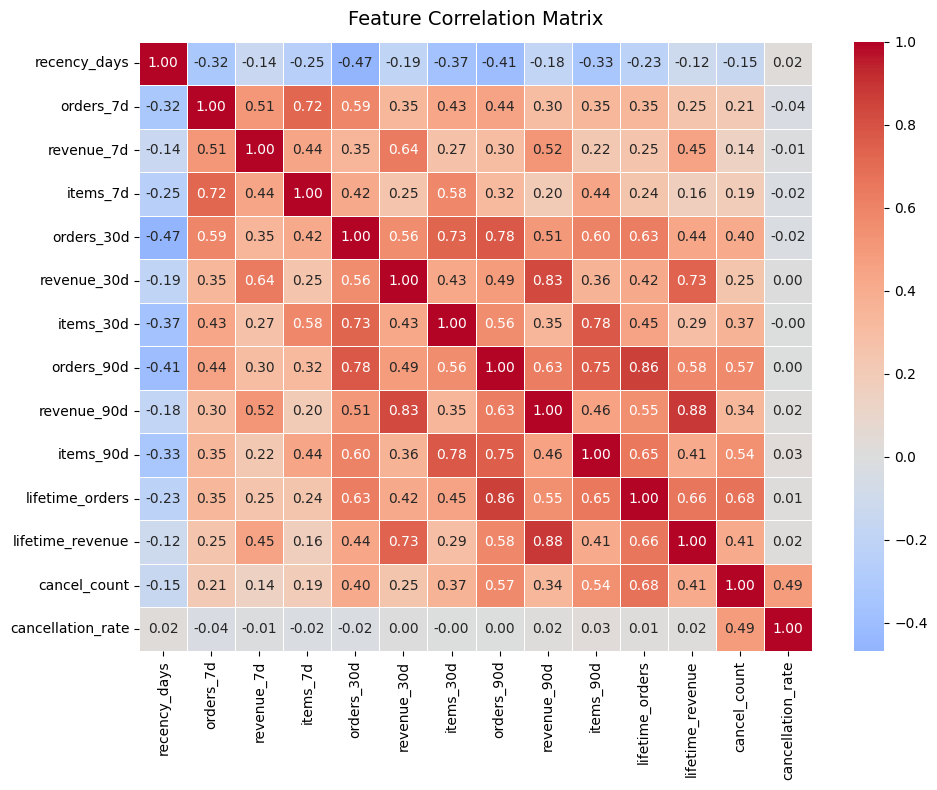

          feature       VIF
       orders_90d 15.867639
  lifetime_orders 11.653237
      revenue_90d 10.695081
       orders_30d  8.804937
 lifetime_revenue  8.035816
        items_30d  7.386671
        items_90d  7.282031
      revenue_30d  5.634536
     cancel_count  3.905153
        orders_7d  3.755017
         items_7d  3.427231
       revenue_7d  2.288033
cancellation_rate  2.048180
     recency_days  1.345342


In [23]:
# ─────────────────────────────────────────────
# Multicollinearity Diagnostics
# ─────────────────────────────────────────────
# Two complementary approaches:
#   1) Pearson correlation heatmap  — shows pairwise linear relationships
#   2) Variance Inflation Factor    — quantifies how much each feature's
#                                     variance is inflated by collinearity

# ── 1. Correlation Heatmap ────────────────────
corr = X_train.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Feature Correlation Matrix", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# ── 2. Variance Inflation Factor (VIF) ───────
# VIF = 1       → no collinearity
# VIF = 1–5     → moderate, generally acceptable
# VIF > 5–10    → high collinearity, warrants attention
# VIF > 10      → severe collinearity

# StandardScaler is fit on X_train inside the pipeline, but VIF is computed
# on raw feature values — collinearity structure is identical either way.
vif_data = pd.DataFrame({
    "feature": feature_cols,
    "VIF": [
        variance_inflation_factor(X_train.values, i)
        for i in range(X_train.shape[1])
    ]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print(vif_data.to_string(index=False))

## Multicollinearity Diagnostics

**Correlation Matrix** and **Variance Inflation Factor (VIF)** analysis confirm
significant multicollinearity across the feature set — particularly among the
overlapping time-window features. The cancellation features stand apart as
notably well-behaved additions.

**Key findings — existing features:**
- `orders_90d` (VIF = 15.87) and `lifetime_orders` (VIF = 11.65) exceed the
  severe collinearity threshold of 10, meaning these features carry heavily
  redundant information.
- All medium/long-window features (`orders_30d`, `items_30d`, `items_90d`,
  `lifetime_revenue`) fall in the 7–9 range — high but not severe.
- The 7-day features and `recency_days` are the least collinear among the
  existing features (VIF < 4), as expected given their narrower scope.
- The correlation matrix confirms the source: shorter windows are nested inside
  longer ones, and revenue/items features within the same window are highly
  correlated with each other.

**Key findings — cancellation features:**
- `cancellation_rate` (VIF = 2.05) is the second least collinear feature in
  the entire set, behind only `recency_days` (VIF = 1.35). Its correlation
  with every other feature is effectively zero — the entire row in the
  correlation matrix is grey. This orthogonality means it adds genuinely
  independent information without compounding the existing multicollinearity.
- `cancel_count` (VIF = 3.91) shows moderate correlation with `lifetime_orders`
  (0.68) and `orders_90d` (0.57), which is intuitive — customers who place more
  orders have more opportunities to cancel. Still well within acceptable range.

**Implication for coefficient interpretation:**

The counterintuitive positive coefficients on `orders_7d`, `orders_30d`,
`items_7d`, and `items_30d` are explained by multicollinearity — the model
cannot cleanly isolate each correlated feature's contribution, causing
coefficient instability and sign flipping. The negative long-window features
(`lifetime_orders`, `orders_90d`) capture the "loyal customer" signal while
the shorter-window features absorb residual variance in unexpected directions.

**Importantly, this does not affect predictive performance** — ROC-AUC and
PR-AUC are rank-based metrics unaffected by coefficient instability. However,
individual coefficients should not be interpreted causally in isolation.
`recency_days` (VIF = 1.35) and `cancellation_rate` (VIF = 2.05) remain the
two cleanest interpretable predictors in the feature set.

## Summary — Logistic Regression Baseline

The logistic regression model achieves ROC-AUC of ~0.699 and PR-AUC of ~0.810
on the held-out test set — strong performance for an untuned linear baseline.

The dominant predictors are consistent with business intuition: recency is the
strongest positive predictor of churn, and long-term order history is the
strongest protective signal. Counterintuitive short-window coefficients are
explained by multicollinearity rather than genuine causal relationships.

The default 0.5 threshold is suboptimal and will be tuned in notebook 04.
Lift analysis below quantifies the business value of model-driven targeting.

## Lift and Decile Analysis

If outreach budget is constrained and only a subset of at-risk customers can
be contacted, does the model help concentrate true churners at the top of the
ranked list more efficiently than random selection?

Lift analysis answers this by dividing customers into deciles by predicted
churn probability and measuring how much more concentrated true churners are
in the highest-risk deciles compared to the overall base rate.

**Definitions:**
- **Capture rate:** The fraction of all true churners captured by targeting
  the top X% of customers by model score
- **Lift:** The churn rate within the targeted segment divided by the overall
  base churn rate — how many times better than random targeting

In [24]:
# ─────────────────────────────────────────────────────────────
# Lift Analysis — Setup
# Build evaluation dataframe with true labels and predictions
# ─────────────────────────────────────────────────────────────

eval_df = pd.DataFrame({
    "y_true":  y_test.values,
    "p_churn": proba_test
})

base_rate = eval_df["y_true"].mean()

print(f"Rows: {len(eval_df):,}")
print(f"Base churn rate: {base_rate:.4f} ({base_rate:.1%})")

Rows: 36,552
Base churn rate: 0.6894 (68.9%)


In [25]:
# ─────────────────────────────────────────────────────────────
# Decile Table Construction
# ─────────────────────────────────────────────────────────────

eval_df["decile"] = pd.qcut(
    eval_df["p_churn"], q=10, labels=False, duplicates="drop"
) + 1

decile_table = (
    eval_df
    .groupby("decile")
    .agg(
        n          =("y_true", "size"),
        churners   =("y_true", "sum"),
        churn_rate =("y_true", "mean"),
        avg_score  =("p_churn", "mean"),
    )
    .reset_index()
)

decile_table["lift"] = decile_table["churn_rate"] / base_rate
decile_table = decile_table.sort_values(
    "decile", ascending=False
).reset_index(drop=True)

print(decile_table.to_string(index=False))

 decile    n  churners  churn_rate  avg_score     lift
     10 3656      3168    0.866521   0.812542 1.256918
      9 3655      3015    0.824897   0.759761 1.196542
      8 3655      2861    0.782763   0.718622 1.135425
      7 3655      2811    0.769083   0.659005 1.115581
      6 3655      2854    0.780848   0.602597 1.132647
      5 3655      2725    0.745554   0.558692 1.081451
      4 3655      2524    0.690561   0.503932 1.001682
      3 3655      2251    0.615869   0.430626 0.893338
      2 3655      1945    0.532148   0.317247 0.771898
      1 3656      1045    0.285832   0.116281 0.414608


The highest-risk decile (decile 10) contains customers with a churn rate
meaningfully above the base rate, confirming the model concentrates true
churners at the top of the ranked list. Cumulative metrics are computed below.

In [26]:
# ─────────────────────────────────────────────────────────────
# Cumulative Metrics
# ─────────────────────────────────────────────────────────────

decile_table["cum_customers"]    = decile_table["n"].cumsum()
decile_table["cum_churners"]     = decile_table["churners"].cumsum()

total_customers = decile_table["n"].sum()
total_churners  = decile_table["churners"].sum()

decile_table["cum_pct_customers"] = (
    decile_table["cum_customers"] / total_customers
)
decile_table["cum_capture_rate"] = (
    decile_table["cum_churners"] / total_churners
)
decile_table["cum_churn_rate"] = (
    decile_table["cum_churners"] / decile_table["cum_customers"]
)
decile_table["cum_lift"] = decile_table["cum_churn_rate"] / base_rate

print(decile_table[[
    "decile", "n", "churn_rate", "lift",
    "cum_pct_customers", "cum_capture_rate", "cum_lift"
]].to_string(index=False))

 decile    n  churn_rate     lift  cum_pct_customers  cum_capture_rate  cum_lift
     10 3656    0.866521 1.256918           0.100022          0.125719  1.256918
      9 3655    0.824897 1.196542           0.200016          0.245367  1.226734
      8 3655    0.782763 1.135425           0.300011          0.358903  1.196300
      7 3655    0.769083 1.115581           0.400005          0.470455  1.176122
      6 3655    0.780848 1.132647           0.500000          0.583714  1.167427
      5 3655    0.745554 1.081451           0.599995          0.691853  1.153099
      4 3655    0.690561 1.001682           0.699989          0.792016  1.131468
      3 3655    0.615869 0.893338           0.799984          0.881344  1.101703
      2 3655    0.532148 0.771898           0.899978          0.958530  1.065059
      1 3656    0.285832 0.414608           1.000000          1.000000  1.000000


In [27]:
# -------------------------
# 6) Top 10% capture:
#    Take the top 10% by predicted risk and compute:
#    - capture rate (recall within targeted subset)
#    - churn rate within targeted subset
#    - lift within targeted subset
# -------------------------
top_frac = 0.10
n_top = int(np.ceil(len(eval_df) * top_frac))

# Rank customers by predicted churn risk (descending)
eval_sorted = eval_df.sort_values("p_churn", ascending=False).reset_index(drop=True)

top_segment = eval_sorted.head(n_top)

top_capture = top_segment["y_true"].sum() / eval_sorted["y_true"].sum()
top_churn_rate = top_segment["y_true"].mean()
top_lift = top_churn_rate / base_rate

print(f"Top {int(top_frac*100)}% segment size: {n_top} customers")
print(f"Base churn rate: {base_rate:.3f}")
print(f"Top {int(top_frac*100)}% churn rate: {top_churn_rate:.3f}")
print(f"Top {int(top_frac*100)}% lift: {top_lift:.3f}")
print(f"Top {int(top_frac*100)}% capture rate: {top_capture:.3f}")

Top 10% segment size: 3656 customers
Base churn rate: 0.689
Top 10% churn rate: 0.867
Top 10% lift: 1.257
Top 10% capture rate: 0.126


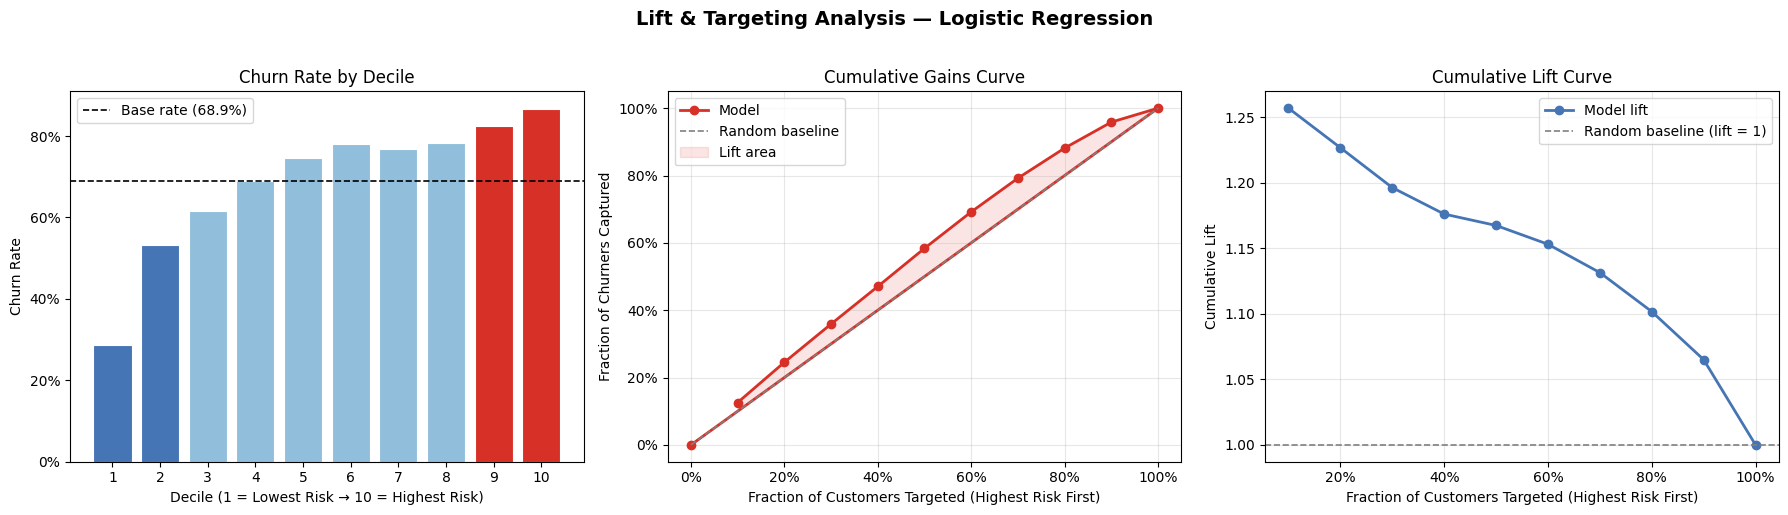

In [28]:
# ─────────────────────────────────────────────────────────────
# Enhanced Lift / Decile Analysis
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Lift & Targeting Analysis — Logistic Regression", fontsize=14, fontweight="bold", y=1.02)

# ── Plot 1: Churn Rate by Decile (Bar Chart) ──────────────────
ax1 = axes[0]
decile_plot = decile_table.sort_values("decile", ascending=True)
bars = ax1.bar(
    decile_plot["decile"],
    decile_plot["churn_rate"],
    color=["#d73027" if d >= 9 else "#4575b4" if d <= 2 else "#91bfdb"
           for d in decile_plot["decile"]],
    edgecolor="white", linewidth=0.8
)
ax1.axhline(base_rate, color="black", linestyle="--", linewidth=1.2, label=f"Base rate ({base_rate:.1%})")
ax1.set_xlabel("Decile (1 = Lowest Risk → 10 = Highest Risk)")
ax1.set_ylabel("Churn Rate")
ax1.set_title("Churn Rate by Decile")
ax1.set_xticks(range(1, 11))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax1.legend()

# ── Plot 2: Cumulative Gains Curve ───────────────────────────
ax2 = axes[1]
# Prepend (0, 0) so curve starts at origin
x_gains = [0] + list(decile_table.sort_values("decile")["cum_pct_customers"])
y_gains = [0] + list(decile_table.sort_values("decile")["cum_capture_rate"])

ax2.plot(x_gains, y_gains, marker="o", color="#d73027", linewidth=2, label="Model")
ax2.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.2, label="Random baseline")
ax2.fill_between(x_gains, x_gains, y_gains, alpha=0.12, color="#d73027", label="Lift area")
ax2.set_xlabel("Fraction of Customers Targeted (Highest Risk First)")
ax2.set_ylabel("Fraction of Churners Captured")
ax2.set_title("Cumulative Gains Curve")
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax2.legend()
ax2.grid(True, alpha=0.3)

# ── Plot 3: Cumulative Lift Curve ─────────────────────────────
ax3 = axes[2]
x_lift = list(decile_table.sort_values("decile")["cum_pct_customers"])
y_lift = list(decile_table.sort_values("decile")["cum_lift"])

ax3.plot(x_lift, y_lift, marker="o", color="#4575b4", linewidth=2, label="Model lift")
ax3.axhline(1.0, linestyle="--", color="gray", linewidth=1.2, label="Random baseline (lift = 1)")
ax3.set_xlabel("Fraction of Customers Targeted (Highest Risk First)")
ax3.set_ylabel("Cumulative Lift")
ax3.set_title("Cumulative Lift Curve")
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Business Interpretation

The lift analysis answers a concrete operational question: **if we can only reach
a subset of at-risk customers, how much more efficient is model-driven targeting
vs. random outreach?**

**Decile breakdown:** The model's discrimination power is most pronounced at the
extremes. The lowest-risk decile (decile 1) has a churn rate of ~29% — less than
half the base rate of ~69%. The highest-risk decile (decile 10) reaches ~87%
churn rate, meaningfully above the base rate. Notably, deciles 4–8 cluster
tightly around the base rate (69–79%), meaning the model's primary value is in
confidently identifying who is *safe to ignore* and who is *highest priority*
— not in separating the middle of the pack.

**Cumulative gains:** By targeting only the top 30% of customers ranked by model
score, we capture ~36% of all true churners. This means a re-engagement campaign
targeting the top 30% would recover a disproportionate share of at-risk customers
at less than a third of the cost of contacting everyone.

**Top 10% capture:** Targeting just the highest-risk 10% of customers yields a
churn rate of ~87% vs. a base rate of ~69% — a lift of approximately 1.26x.
While modest in magnitude, this reflects the nature of the problem: with a ~69%
base churn rate, most customers are already at risk, leaving limited headroom
for lift. The model's value is less about finding a needle in a haystack and
more about **prioritizing the highest-certainty churners** when outreach budget
is constrained.

**Impact of cancellation features on targeting:** Adding cancellation features
produced no meaningful change in lift or targeting efficiency for the logistic
regression model — top 10% lift moved from 1.253 to 1.257, within noise range.
This is consistent with the flat ROC-AUC and is expected given the sparse,
nonlinear nature of the cancellation signal. Whether these features improve
targeting efficiency in the XGBoost model will be evaluated in notebook 05.

**Practical implication:** In a real deployment scenario, this model would plug
directly into a CRM or marketing automation tool. Each week, the model scores
all active customers, and the top-scoring segment is automatically flagged for
outreach — whether that's a discount offer, a personalized email, or a customer
success call. The lift curve quantifies exactly how much budget efficiency that
buys compared to untargeted outreach.

In [29]:
# ─────────────────────────────────────────────────────────────
# Persist Test Set Predictions
# Saved for threshold tuning and regularization analysis
# in notebook 04
# ─────────────────────────────────────────────────────────────

out_dir = Path("../data/processed")

lr_predictions = pd.DataFrame({
    "y_true":  y_test.values,
    "p_churn": proba_test,
})

lr_predictions.to_parquet(
    out_dir / "lr_test_predictions.parquet", index=False
)
print("Saved lr_test_predictions.parquet — shape:", lr_predictions.shape)

Saved lr_test_predictions.parquet — shape: (36552, 2)
